In [4]:
# Libraries

import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm


sys.path.append('../')
from simulation.config import *

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
dataset = np.load('../particle_dataset.npy')  # Shape: (100, 303, 100, 4)
print(f'Dataset shape: {dataset.shape}')

Dataset shape: (100, 302, 100, 11)


In [3]:
num_trials, max_timesteps, num_particles, num_features = dataset.shape

In [5]:
# Select a single particle
particle_idx = 0
single_particle_data = dataset[:, :, particle_idx, :]  # Shape: (100, 303, 11)

# Create input-output pairs using normalized data
N, T_max, _ = single_particle_data.shape
inputs = []
targets = []

for trial_idx in range(N):
    for t in range(T_max - 1):  # T_max-1 to get next state
        # Input: [x, y, vx, vy, e, vx0, vy0, g, Δt, x_min, x_max]
        input_vec = single_particle_data[trial_idx, t, :]
        # Target: Next state [x(t+Δt), y(t+Δt), vx(t+Δt), vy(t+Δt)]
        target_vec = single_particle_data[trial_idx, t + 1, :4]  # Only [x, y, vx, vy]
        inputs.append(input_vec)
        targets.append(target_vec)

inputs = np.array(inputs, dtype=np.float32)  # Shape: (N*(T_max-1), 11)
targets = np.array(targets, dtype=np.float32)  # Shape: (N*(T_max-1), 4)
print(f'Inputs shape: {inputs.shape}, Targets shape: {targets.shape}')

Inputs shape: (30100, 11), Targets shape: (30100, 4)


In [6]:
# Neural Network Architecture
class ParticleNet(nn.Module):
    def __init__(self):
        super(ParticleNet, self).__init__()
        # First hidden layer: Predict free motion state [x', y', vx', vy']
        # 6 neurons: 2 for x', 3 for y', 1 for vx', 1 for vy'
        self.free_motion = nn.Sequential(
            nn.Linear(11, 6),  # Input: [x, y, vx, vy, e, vx0, vy0, g, Δt, x_min, x_max]
            nn.ReLU(),
            nn.Linear(6, 4)  # Output: [x', y', vx', vy']
        )
        # Second hidden layer: Predict collision flags [c_ground, c_left, c_right]
        # 6 neurons: 2 per collision flag
        self.collision_detection = nn.Sequential(
            nn.Linear(4, 6),  # Input: [x', y', vx', vy']
            nn.ReLU(),
            nn.Linear(6, 3),  # Output: [c_ground, c_left, c_right]
            nn.Sigmoid()  # Collision probabilities
        )
        # Third hidden layer: Final state adjustment
        # 8 neurons: 2 per output (x, y, vx, vy)
        self.final_state = nn.Sequential(
            nn.Linear(7, 8),  # Input: [x', y', vx', vy', c_ground, c_left, c_right]
            nn.ReLU(),
            nn.Linear(8, 4)  # Output: [x(t+Δt), y(t+Δt), vx(t+Δt), vy(t+Δt)]
        )

    def forward(self, x):
        # Free motion prediction
        free_motion_state = self.free_motion(x)  # [x', y', vx', vy']
        # Collision detection
        collision_flags = self.collision_detection(free_motion_state)  # [c_ground, c_left, c_right]
        # Concatenate free motion state and collision flags
        combined = torch.cat((free_motion_state, collision_flags), dim=1)
        # Final state prediction
        final_state = self.final_state(combined)  # [x(t+Δt), y(t+Δt), vx(t+Δt), vy(t+Δt)]
        return final_state

In [7]:
class ParticleNetSCFC(nn.Module):
    """
    A neural network for predicting the next state of a single particle in a 2D environment,
    governed by Newtonian mechanics with gravity and elastic collisions with boundaries.
    The architecture is designed to model free motion and collision dynamics, using a modular
    structure with skip connections and feature concatenation to ensure effective utilization
    of input features across layers.

    The input vector consists of 11 features:
    [x, y, vx, vy, e, vx0, vy0, g, Δt, x_min, x_max], representing the current position,
    velocity, coefficient of restitution, initial velocities, gravitational acceleration,
    time step, and boundary positions. The output is the next state [x(t+Δt), y(t+Δt),
    vx(t+Δt), vy(t+Δt)].

    The architecture addresses the limitation of underutilized input features (e.g., e, x_min,
    x_max) in earlier layers by incorporating skip connections and feature concatenation:
    - Skip connections pass critical features (e, x_min, x_max) directly to the collision
      detection and final state layers, bypassing earlier transformations.
    - Feature concatenation combines these inputs with intermediate outputs (e.g., free motion
      state, collision flags), ensuring that physically relevant features are available where
      needed (e.g., e for collision response, x_min/x_max for boundary detection).

    Attributes:
        free_motion (nn.Sequential): Predicts the free motion state [x', y', vx', vy']
            using the full input vector.
        collision_detection (nn.Sequential): Detects collisions [c_ground, c_left, c_right]
            using the free motion state concatenated with e, x_min, and x_max.
        final_state (nn.Sequential): Adjusts the state for collisions, using the free motion
            state, collision flags, and e to produce the final next state.

    Args:
        None

    Methods:
        forward(x): Processes the input tensor through the network, applying skip connections
            and feature concatenation to produce the next state.
    """
    def __init__(self):
        super(ParticleNetSCFC, self).__init__()
        # First hidden layer: Predict free motion state [x', y', vx', vy']
        self.free_motion = nn.Sequential(
            nn.Linear(8, 6),  # Input: [x, y, vx, vy, e, vx0, vy0, g, Δt, x_min, x_max]
            nn.ReLU(),
            nn.Linear(6, 4)  # Output: [x', y', vx', vy']
        )
        # Second hidden layer: Collision detection
        self.collision_detection = nn.Sequential(
            nn.Linear(7, 6),  # Input: [x', y', vx', vy', e, x_min, x_max]
            nn.ReLU(),
            nn.Linear(6, 3),  # Output: [c_ground, c_left, c_right]
            nn.Sigmoid()  # Collision probabilities
        )
        # Third hidden layer: Final state adjustment
        self.final_state = nn.Sequential(
            nn.Linear(8, 8),  # Input: [x', y', vx', vy', c_ground, c_left, c_right, e]
            nn.ReLU(),
            nn.Linear(8, 4)  # Output: [x(t+Δt), y(t+Δt), vx(t+Δt), vy(t+Δt)]
        )

    def forward(self, x):
        """
        Forward pass through the network, applying skip connections and feature concatenation.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 11), containing
                [x, y, vx, vy, e, vx0, vy0, g, Δt, x_min, x_max].

        Returns:
            torch.Tensor: Output tensor of shape (batch_size, 4), containing the predicted
                next state [x(t+Δt), y(t+Δt), vx(t+Δt), vy(t+Δt)].
        """
        # Extract relevant input features
        state = x[:, :4]  # [x, y, vx, vy]
        e = x[:, 4:5]     # [e]
        bounds = x[:, 9:11]  # [x_min, x_max]
        
        # Free motion prediction
        x = torch.cat((state, x[:, 5:9]), dim=1)  # Concatenate with [vx0, vy0, g, Δt]
        free_motion_state = self.free_motion(x)  # [x', y', vx', vy']
        
        # Collision detection: Concatenate free motion state with e, x_min, x_max
        collision_input = torch.cat((free_motion_state, e, bounds), dim=1)  # [x', y', vx', vy', e, x_min, x_max]
        collision_flags = self.collision_detection(collision_input)  # [c_ground, c_left, c_right]
        
        # Final state: Concatenate free motion state, collision flags, and e
        final_input = torch.cat((free_motion_state, collision_flags, e), dim=1)  # [x', y', vx', vy', c_ground, c_left, c_right, e]
        final_state = self.final_state(final_input)  # [x(t+Δt), y(t+Δt), vx(t+Δt), vy(t+Δt)]
        
        return final_state

In [8]:
inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
targets = torch.tensor(targets, dtype=torch.float32).to(device)

# Dataset Split (80% train, 10% validation, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(inputs, targets, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f'Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}')

Train: torch.Size([24080, 11]), Validation: torch.Size([3010, 11]), Test: torch.Size([3010, 11])


In [9]:
model = ParticleNetSCFC().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [10]:
# Training Loop with tqdm
num_epochs = 100
batch_size = 128
train_losses = []
val_losses = []

for epoch in tqdm(range(num_epochs), desc="Training Epochs"):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    
    # Mini-batch training
    epoch_train_loss = 0
    for i in range(0, X_train.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_X = X_train[indices]
        batch_y = y_train[indices]
        
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item() * batch_X.size(0)
    
    epoch_train_loss /= X_train.size(0)
    train_losses.append(epoch_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val).item()
        val_losses.append(val_loss)
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {epoch_train_loss:.6f}, '
              f'Val Loss: {val_loss:.6f}')

Training Epochs:  10%|█         | 10/100 [00:08<01:16,  1.18it/s]

Epoch [10/100], Train Loss: 200.732046, Val Loss: 393.970673


Training Epochs:  20%|██        | 20/100 [00:16<01:02,  1.28it/s]

Epoch [20/100], Train Loss: 199.669200, Val Loss: 393.575073


Training Epochs:  30%|███       | 30/100 [00:24<00:55,  1.26it/s]

...

Epoch [80/100], Train Loss: 200.270670, Val Loss: 395.885712


Training Epochs:  90%|█████████ | 90/100 [01:12<00:07,  1.33it/s]

Epoch [90/100], Train Loss: 201.000251, Val Loss: 393.596405


Training Epochs: 100%|██████████| 100/100 [01:20<00:00,  1.24it/s]

Epoch [100/100], Train Loss: 201.234467, Val Loss: 398.170990


In [12]:
# Evaluate on Test Set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    # Denormalize for loss computation in original scale
    test_outputs_np = test_outputs.cpu().numpy()
    y_test_np = y_test.cpu().numpy()
    # Compute test loss in original scale
    test_outputs_tensor = torch.tensor(test_outputs, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).to(device)
    test_loss = criterion(test_outputs_tensor, y_test_tensor).item()
    print(f'Test Loss (original scale): {test_loss:.6f}')


Test Loss (original scale): 339.651428


C:\Users\amine\AppData\Local\Temp\ipykernel_17396\1520399076.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_outputs_tensor = torch.tensor(test_outputs, dtype=torch.float32).to(device)


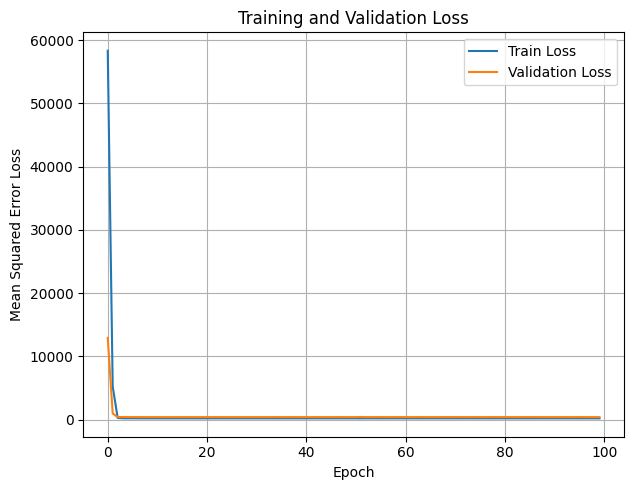

In [13]:
# %%
# Plot Training and Validation Metrics
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Save the Model
model_name = 'particle_net_scfc'
torch.save(model.state_dict(), f'../models/{model_name}.pth')
print(f'Model saved as {model_name}.pth')

Model saved as particle_net_scfc.pth
